# Clasificación de reseñas de hoteles con Word2Vec y LSTM

Este notebook desarrolla las siete secciones del entregable. Cada celda de código está precedida por una explicación. Ejecuta las celdas en orden con el kernel del entorno del proyecto.

**Preparación con uv:** desde la carpeta del proyecto ejecuta `uv sync` y después `uv run jupyter lab`. Selecciona el Python de `.venv`. Las dependencias se declaran en `pyproject.toml`; `uv.lock`, cuando se genere, fija sus versiones exactas. No se instalan paquetes automáticamente dentro del kernel.

**Recursos:** Word2Vec Google News ocupa aproximadamente 1.74 GB comprimido; su carga completa requiere varios GB de RAM. La descarga se almacena en `data/embeddings`. El entrenamiento con padding previo y máscara usa la implementación nativa de LSTM, que puede tardar varios minutos o más en CPU.

**Objetivo:** `text` → `polarity`, con negativa = 0 y positiva = 1. Word2Vec aporta representaciones preentrenadas congeladas; la LSTM y la salida aprenden el sentimiento. No entrenamos Word2Vec ni utilizamos `deceptive` como etiqueta.

### 0.1 · Importaciones y reproducibilidad

Cargamos las librerías del entorno uv, fijamos semillas y limitamos los hilos para no saturar la máquina. Registramos versiones. La reproducibilidad puede variar entre equipos y versiones; el conjunto de prueba no guiará ajustes.

In [1]:
import os
from pathlib import Path
import sys, re, json, html, hashlib, gc
from collections import Counter
from importlib.metadata import version

ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    raise RuntimeError("Abre Jupyter desde la raíz del proyecto: uv run jupyter lab")
DATA_DIR = ROOT / "data"
EMBED_DIR = DATA_DIR / "embeddings"
ARTIFACT_DIR = ROOT / "artifacts"
for directory in (DATA_DIR, EMBED_DIR, ARTIFACT_DIR):
    directory.mkdir(parents=True, exist_ok=True)
os.environ["GENSIM_DATA_DIR"] = str(EMBED_DIR)
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".cache" / "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import pad_sequences
import gensim.downloader as api
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, ConfusionMatrixDisplay)
from sklearn.dummy import DummyClassifier
from IPython.display import display, Markdown

SEED = 42
keras.utils.set_random_seed(SEED)
try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    tf.config.threading.set_inter_op_parallelism_threads(2)
except RuntimeError:
    print("TensorFlow ya estaba inicializado; se conserva su configuración de hilos.")
tf.config.experimental.enable_op_determinism()
VERSIONS = {name: version(name) for name in
            ["tensorflow", "keras", "gensim", "numpy", "pandas", "scikit-learn", "matplotlib"]}
print("Python:", sys.version.split()[0])
display(pd.Series(VERSIONS, name="versión").to_frame())
print("GPU:", tf.config.list_physical_devices("GPU"))


Python: 3.12.3


,versión
tensorflow,2.20.0
keras,3.15.1
gensim,4.4.0
numpy,2.2.6
pandas,2.3.3
scikit-learn,1.9.0
matplotlib,3.11.1


GPU: []


E0000 00:00:1788846677.950907   72594 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788846677.959630   72594 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## 1. Exploración de los datos

Revisaremos estructura, calidad y distribución de etiquetas. Las longitudes que determinen hiperparámetros se estudiarán después, usando exclusivamente entrenamiento.

### 1.1 · Leer el CSV

Preferimos el archivo local; si falta, leemos la URL de la tarea y conservamos una copia. Registramos una huella del archivo para identificar los datos usados.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/AnIsAsPe/LogisticRegression_SpamOpinion/master/Datos/deceptive-opinion.csv"
CSV_PATH = DATA_DIR / "deceptive-opinion.csv"
if not CSV_PATH.exists():
    pd.read_csv(DATA_URL).to_csv(CSV_PATH, index=False)
raw = pd.read_csv(CSV_PATH)
DATA_SHA256 = hashlib.sha256(CSV_PATH.read_bytes()).hexdigest()
assert {"text", "polarity"}.issubset(raw.columns)
print("Forma:", raw.shape, "| SHA256:", DATA_SHA256)
display(raw.head(3))
raw.info()


Forma: (1600, 5) | SHA256: e98f9f9497fb9e056b7f5870b2fd551e706dcca8de3fd8269f9f1f0de71e3a77


,deceptive,hotel,polarity,source,text
0,truthful,conrad,positive,TripAdvisor,We stayed for a one night getaway with family ...
1,truthful,hyatt,positive,TripAdvisor,Triple A rate with upgrade to view room was le...
2,truthful,hyatt,positive,TripAdvisor,This comes a little late as I'm finally catchi...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   deceptive  1600 non-null   object
 1   hotel      1600 non-null   object
 2   polarity   1600 non-null   object
 3   source     1600 non-null   object
 4   text       1600 non-null   object
dtypes: object(5)
memory usage: 62.6+ KB


### 1.2 · Revisar calidad y clases

Mostramos nulos, clases, textos repetidos y la relación entre polaridad y autenticidad. Esta relación será una limitación a considerar, no una característica del clasificador.

,nulos
deceptive,0
hotel,0
polarity,0
source,0
text,0


,reseñas
polarity,
positive,800
negative,800


Textos repetidos: 4


polarity,negative,positive
deceptive,,
deceptive,400,400
truthful,400,400


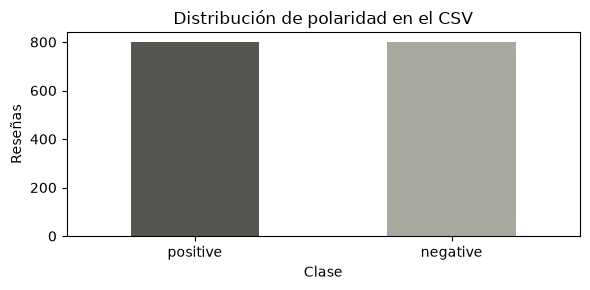

In [3]:
display(raw.isna().sum().rename("nulos").to_frame())
display(raw["polarity"].value_counts(dropna=False).rename("reseñas").to_frame())
print("Textos repetidos:", raw["text"].duplicated().sum())
display(pd.crosstab(raw["deceptive"], raw["polarity"]))
fig, ax = plt.subplots(figsize=(6, 3))
raw["polarity"].value_counts().plot.bar(ax=ax, color=["#555650", "#aaa99f"])
ax.set(title="Distribución de polaridad en el CSV", xlabel="Clase", ylabel="Reseñas")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 2. Preprocesamiento de textos

Eliminaremos textos inválidos y duplicados antes de dividir. Conservaremos negaciones y orden. Las reglas de limpieza serán fijas, no aprendidas del conjunto de prueba.

### 2.1 · Limpiar registros y resolver duplicados

Identificamos duplicados ignorando diferencias de espacios y mayúsculas. Si un mismo texto tiene etiquetas contradictorias, detenemos el flujo para revisarlo en lugar de decidir arbitrariamente.

In [4]:
df = raw.dropna(subset=["text", "polarity"]).copy()
df["text"] = df["text"].astype(str).str.strip()
df = df[df["text"].ne("")].copy()
LABEL_MAP = {"negative": 0, "positive": 1}
unexpected = set(df["polarity"]) - set(LABEL_MAP)
assert not unexpected, f"Etiquetas no previstas: {unexpected}"
df["duplicate_key"] = df["text"].str.replace(r"\s+", " ", regex=True).str.casefold()
conflicts = df.groupby("duplicate_key")["polarity"].nunique()
assert not (conflicts > 1).any(), "Revisar textos con polaridad contradictoria."
df = df.drop_duplicates("duplicate_key").reset_index(drop=True)
df["label"] = df["polarity"].map(LABEL_MAP).astype("int32")
print(f"Registros originales: {len(raw)}; válidos únicos: {len(df)}")


Registros originales: 1600; válidos únicos: 1596


### 2.2 · Tokenizar conservando negaciones

Normalizamos HTML y apóstrofos, expandimos contracciones negativas y extraemos palabras en inglés. Conservamos mayúsculas porque Google News distingue el caso; al buscar embeddings intentaremos la palabra exacta y después su minúscula. No eliminamos stopwords ni aplicamos stemming. Estas reglas no se ajustan usando prueba.

In [5]:
TOKEN_PATTERN = r"[A-Za-z]+(?:'[A-Za-z]+)?"
def tokenize(text):
    text = html.unescape(str(text)).replace("’", "'")
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\bwon't\b", "will not", text, flags=re.I)
    text = re.sub(r"\bcan't\b", "can not", text, flags=re.I)
    text = re.sub(r"\bshan't\b", "shall not", text, flags=re.I)
    text = re.sub(r"n't\b", " not", text, flags=re.I)
    return re.findall(TOKEN_PATTERN, text)

df["tokens"] = df["text"].map(tokenize)
empty_count = df["tokens"].map(len).eq(0).sum()
df = df[df["tokens"].map(len).gt(0)].copy()
# Evitar que entradas idénticas después de tokenizar crucen las particiones.
df["token_key"] = df["tokens"].map(lambda tokens: " ".join(tokens).casefold())
assert not (df.groupby("token_key")["label"].nunique() > 1).any(), "Revisar conflicto tras tokenizar."
df = df.drop_duplicates("token_key").reset_index(drop=True)
print("Textos sin tokens descartados:", empty_count)
display(df[["text", "tokens", "label"]].head(3))
assert "not" in tokenize("The room wasn't clean.")


Textos sin tokens descartados: 0


,text,tokens,label
0,We stayed for a one night getaway with family ...,"[We, stayed, for, a, one, night, getaway, with...",1
1,Triple A rate with upgrade to view room was le...,"[Triple, A, rate, with, upgrade, to, view, roo...",1
2,This comes a little late as I'm finally catchi...,"[This, comes, a, little, late, as, I'm, finall...",1


### 2.3 · Separar entrenamiento, validación y prueba

Usamos aproximadamente 70/15/15 con estratificación y semilla fija. Los duplicados se resolvieron antes. Esta evaluación mide reseñas del mismo corpus; no garantiza generalización a hoteles nuevos. No utilizaremos el texto de validación o prueba para construir el vocabulario ni elegir la longitud.

In [6]:
train_df, holdout_df = train_test_split(
    df, test_size=0.30, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(
    holdout_df, test_size=0.50, stratify=holdout_df["label"], random_state=SEED)
splits = {"entrenamiento": train_df, "validación": val_df, "prueba": test_df}
for a, b in [(train_df, val_df), (train_df, test_df), (val_df, test_df)]:
    assert set(a["token_key"]).isdisjoint(b["token_key"])
display(pd.DataFrame({
    name: part["label"].value_counts().reindex([0, 1], fill_value=0)
    for name, part in splits.items()
}).rename(index={0: "negativa", 1: "positiva"}))


,entrenamiento,validación,prueba
label,,,
negativa,557,119,120
positiva,560,120,120


## 3. Vectorización de texto: secuencias de entrada

Cada token recibe un identificador. Estos enteros son índices, no significados ni puntuaciones de sentimiento. La capa Embedding los utilizará para buscar vectores.

### 3.1 · Crear el vocabulario de entrenamiento

Incluimos todas las palabras observadas en entrenamiento, ordenadas por frecuencia de forma reproducible. Reservamos 0 para relleno y 1 para desconocidas. El vocabulario queda fijo después de esta celda.

In [7]:
PAD_ID, UNK_ID = 0, 1
counts = Counter(token for tokens in train_df["tokens"] for token in tokens)
ordered_words = sorted(counts, key=lambda word: (-counts[word], word))
word_index = {word: i + 2 for i, word in enumerate(ordered_words)}
V = len(word_index) + 2
index_word = {PAD_ID: "<PAD>", UNK_ID: "<UNK>", **{i: w for w, i in word_index.items()}}
print("V (incluye especiales):", V)
display(pd.DataFrame([(w, word_index[w], counts[w]) for w in ordered_words[:12]],
                     columns=["palabra", "índice", "frecuencia en entrenamiento"]))


V (incluye especiales): 9351


,palabra,índice,frecuencia en entrenamiento
0,the,2,9057
1,and,3,5533
2,to,4,4725
3,a,5,4463
4,was,6,4255
5,I,7,4216
6,in,8,2783
7,of,9,2335
8,The,10,2230
9,for,11,1960


### 3.2 · Elegir la longitud máxima con entrenamiento

Elegimos el percentil 95 de longitudes de entrenamiento: conserva completas aproximadamente el 95% de las reseñas de ese conjunto. Este criterio se fija sin consultar prueba. Mostramos cuánto texto se truncará; padding y truncamiento son decisiones distintas.

L = 323


,tokens
count,1117.000000
mean,151.106535
std,91.054891
min,25.000000
50%,130.000000
90%,264.600000
95%,322.000000
99%,456.840000
max,794.000000


Fracción de reseñas de entrenamiento recortadas: 0.050134288272157566


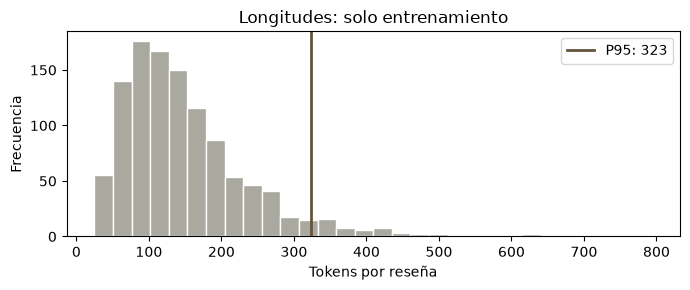

In [8]:
train_lengths = train_df["tokens"].map(len).to_numpy()
MAX_LEN = max(1, int(np.ceil(np.percentile(train_lengths, 95))))
PADDING, TRUNCATING = "pre", "post"
print("L =", MAX_LEN)
display(pd.Series(train_lengths).describe(percentiles=[.5, .9, .95, .99]).to_frame("tokens"))
print("Fracción de reseñas de entrenamiento recortadas:", np.mean(train_lengths > MAX_LEN))
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(train_lengths, bins=30, color="#aaa99f", edgecolor="white")
ax.axvline(MAX_LEN, color="#64543e", label=f"P95: {MAX_LEN}", linewidth=2)
ax.set(xlabel="Tokens por reseña", ylabel="Frecuencia", title="Longitudes: solo entrenamiento")
ax.legend()
plt.tight_layout()
plt.show()


### 3.3 · Convertir a índices y aplicar pad_sequences

Rellenamos al inicio con 0 y recortamos al final, conservando el inicio de las reseñas largas. Las palabras nuevas reciben 1. Las etiquetas quedan en un vector aparte. No modificamos vocabulario o longitud a partir de la cobertura de prueba.

In [9]:
def encode_tokens(tokens, vocabulary):
    return [vocabulary.get(token, UNK_ID) for token in tokens]

def vectorize(token_lists, vocabulary, max_len):
    sequences = [encode_tokens(tokens, vocabulary) for tokens in token_lists]
    return pad_sequences(sequences, maxlen=max_len, dtype="int32",
                         padding=PADDING, truncating=TRUNCATING, value=PAD_ID)

X_train = vectorize(train_df["tokens"], word_index, MAX_LEN)
X_val = vectorize(val_df["tokens"], word_index, MAX_LEN)
X_test = vectorize(test_df["tokens"], word_index, MAX_LEN)
y_train = train_df["label"].to_numpy(dtype="int32")
y_val = val_df["label"].to_numpy(dtype="int32")
y_test = test_df["label"].to_numpy(dtype="int32")
for name, X in [("train", X_train), ("val", X_val), ("test", X_test)]:
    assert X.shape[1] == MAX_LEN and X.min() >= 0 and X.max() < V
    print(name, X.shape, "| desconocidas entre tokens:", (X == UNK_ID).sum() / (X != PAD_ID).sum())
example_tokens = tokenize("The hotel was clean")
print("Tokens:", example_tokens)
print("Índices:", encode_tokens(example_tokens, word_index))
print("Ejemplo con seis posiciones:", vectorize([example_tokens], word_index, 6)[0])


train (1117, 323) | desconocidas entre tokens: 0.0
val (239, 323) | desconocidas entre tokens: 0.02781081328332266
test (240, 323) | desconocidas entre tokens: 0.027518172377985463
Tokens: ['The', 'hotel', 'was', 'clean']
Índices: [10, 13, 6, 81]
Ejemplo con seis posiciones: [ 0  0 10 13  6 81]


## 4. Matriz de vectores Word2Vec preentrenados

Usaremos **word2vec-google-news-300**. Gensim descarga el archivo completo; después seleccionamos los vectores de nuestro vocabulario. La matriz compartida tendrá forma **V × D**. Para una reseña, Embedding seleccionará **L** filas y producirá **L × D**.

Esto es transferencia de representaciones preentrenadas fijas. Los vectores no contienen directamente las reglas del sentimiento: la LSTM y la salida las aprenderán usando las etiquetas.

Fuentes: [catálogo de Gensim](https://github.com/piskvorky/gensim-data/blob/master/list.json) y [API de descarga](https://radimrehurek.com/gensim/downloader.html).

### 4.1 · Descargar Word2Vec y verificar sus metadatos

Gensim administra la descarga, la caché y su comprobación de integridad. La primera ejecución requiere conexión y unos 1.74 GB de descarga. Las siguientes reutilizan el archivo. Si falla la red, esta celda falla explícitamente; no sustituimos Word2Vec por embeddings aleatorios.

In [ ]:
W2V_NAME = "word2vec-google-news-300"
api.BASE_DIR = str(EMBED_DIR)
model_info = api.info(W2V_NAME)
D = int(model_info["parameters"]["dimension"])
assert D == 300
display(pd.Series({k: model_info[k] for k in
                   ["num_records", "file_size", "base_dataset", "file_name"]}).to_frame("valor"))
w2v_path = Path(api.load(W2V_NAME, return_path=True))
assert w2v_path.exists()
print("Archivo disponible:", w2v_path)


### 4.2 · Cargar los vectores

Como en la libreta de referencia, utilizamos KeyedVectors.load_word2vec_format con formato binario. Cargamos todos los vectores para poder buscar las palabras necesarias. Esta celda requiere varios GB de RAM.

In [ ]:
w2v = KeyedVectors.load_word2vec_format(str(w2v_path), binary=True)
assert w2v.vector_size == D
print("Vocabulario preentrenado:", len(w2v.index_to_key))
print("Dimensión:", w2v.vector_size)
print("Vector de hotel:", w2v["hotel"][:8])


### 4.3 · Construir la matriz alineada con los índices

Para cada palabra, copiamos su vector a su fila: E[índice] = vector Word2Vec. Intentamos coincidencia exacta y luego minúscula. Las ausentes y <UNK> recibirán el promedio de los vectores encontrados; el relleno será cero y estará enmascarado. Esta estrategia de respaldo es determinista y evita inventar significado para palabras ausentes.

In [ ]:
embedding_matrix = np.zeros((V, D), dtype=np.float32)
matches = {}
missing_words = []
for word, idx in word_index.items():
    key = word if word in w2v else word.lower()
    if key in w2v:
        embedding_matrix[idx] = w2v[key]
        matches[word] = key
    else:
        missing_words.append(word)
assert matches, "Ninguna palabra coincide: revisar idioma o preprocesamiento."
matched_indices = [word_index[word] for word in matches]
fallback = embedding_matrix[matched_indices].mean(axis=0)
embedding_matrix[UNK_ID] = fallback
for word in missing_words:
    embedding_matrix[word_index[word]] = fallback
assert np.isfinite(embedding_matrix).all()
assert np.all(embedding_matrix[PAD_ID] == 0)
type_coverage = len(matches) / len(word_index)
token_coverage = sum(counts[w] for w in matches) / sum(counts.values())
print(f"Cobertura de palabras distintas: {type_coverage:.2%}")
print(f"Cobertura ponderada por frecuencia de entrenamiento: {token_coverage:.2%}")
print("Matriz:", embedding_matrix.shape, "| MB:", embedding_matrix.nbytes / 1e6)
print("Ejemplos ausentes:", missing_words[:20])
for word in ordered_words[:3]:
    idx = word_index[word]
    print(word, "→ fila", idx, "→", embedding_matrix[idx, :5])


### 4.4 · Guardar matriz y liberar el modelo completo

Conservamos la matriz compacta y un registro de cobertura. Liberamos Google News antes del entrenamiento. Las escrituras se limitan a artifacts; si vuelves a ejecutar, estos resultados del experimento se reemplazan.

In [ ]:
np.save(ARTIFACT_DIR / "embedding_matrix.npy", embedding_matrix)
pd.DataFrame({
    "palabra": ordered_words,
    "indice": [word_index[w] for w in ordered_words],
    "clave_word2vec": [matches.get(w) for w in ordered_words],
    "frecuencia_train": [counts[w] for w in ordered_words],
}).to_csv(ARTIFACT_DIR / "cobertura_word2vec.csv", index=False)
del w2v
gc.collect()
print("Matriz conservada; Word2Vec completo liberado de memoria.")


## 5. Diseño de la RNN

Arquitectura requerida: **Embedding congelado → LSTM de D unidades, dropout 0.2 → Dense de una neurona, sigmoid**.

La LSTM procesa los vectores de una reseña en orden y conserva un estado propio. El batch agrupa reseñas, pero no mezcla sus estados. Al final hay una predicción por reseña.

Usaremos `mask_zero=True`. El requisito `padding='pre'` no cumple la condición de padding a la derecha de cuDNN; por eso elegimos explícitamente `use_cudnn=False`. Puede ser más lento en GPU, pero respeta la tarea y la máscara. [Documentación de LSTM](https://keras.io/api/layers/recurrent_layers/lstm/) y [Embedding](https://keras.io/api/layers/core_layers/embedding/).

### 5.1 · Construir y compilar el modelo

Sigmoid produce un valor entre 0 y 1; binary_crossentropy compara ese valor con la etiqueta. Adam ajusta exclusivamente LSTM y salida. Igualar D y unidades LSTM es un requisito del ejercicio, no una obligación general.

In [ ]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)
model = keras.Sequential([
    keras.Input(shape=(MAX_LEN,), dtype="int32", name="indices"),
    keras.layers.Embedding(
        input_dim=V, output_dim=D,
        embeddings_initializer=keras.initializers.Constant(embedding_matrix),
        trainable=False, mask_zero=True, name="word2vec_congelado"),
    keras.layers.LSTM(D, dropout=0.2, use_cudnn=False, name="lstm"),
    keras.layers.Dense(1, activation="sigmoid", name="polaridad"),
], name="hotel_word2vec_lstm")
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.BinaryAccuracy(name="accuracy")])
model.summary()
assert not model.get_layer("word2vec_congelado").trainable
assert model.get_layer("lstm").units == D
assert model.get_layer("lstm").dropout == 0.2


### 5.2 · Comprobar el recorrido de una reseña

Una entrada tiene L índices. Embedding obtiene L vectores de D números y la salida devuelve una probabilidad. Verificamos que los ceros de relleno estén enmascarados. Estas predicciones iniciales aún no tienen valor como clasificación.

In [ ]:
one_review = X_train[:1]
embedded = model.get_layer("word2vec_congelado")(one_review)
mask = model.get_layer("word2vec_congelado").compute_mask(one_review)
print("Índices:", one_review.shape)
print("Vectores de una reseña:", embedded.shape)
print("Salida:", model(one_review, training=False).shape)
np.testing.assert_array_equal(mask.numpy(), one_review != PAD_ID)
np.testing.assert_allclose(embedded.numpy()[0], embedding_matrix[one_review[0]])


## 6. Entrenamiento y evaluación

El conjunto de validación guía la detención y selección de pesos. Evaluaremos prueba una vez seleccionado el modelo, sin cambiar hiperparámetros ni umbral por sus resultados.

### 6.1 · Preparar lotes y detención temprana

Batch size es un hiperparámetro: agrupa 32 reseñas por actualización. Entrenaremos hasta 12 épocas, con paciencia de 3 y restauración de los mejores pesos según pérdida de validación. El conjunto de prueba no se entrega a fit.

In [ ]:
BATCH_SIZE = 32
MAX_EPOCHS = 12
THRESHOLD = 0.5
def make_dataset(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X), seed=SEED, reshuffle_each_iteration=True)
    options = tf.data.Options()
    options.threading.private_threadpool_size = 2
    return ds.batch(BATCH_SIZE).with_options(options).prefetch(1)

train_ds = make_dataset(X_train, y_train, training=True)
val_ds = make_dataset(X_val, y_val)
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.CSVLogger(str(ARTIFACT_DIR / "training_log.csv"), append=False),
]
embedding_before = model.get_layer("word2vec_congelado").get_weights()[0].copy()


### 6.2 · Entrenar el clasificador

Calculamos predicciones por lote, comparamos con las etiquetas y actualizamos los pesos entrenables. El historial muestra pérdidas y exactitud por época. No se presenta ningún resultado simulado.

In [ ]:
history = model.fit(train_ds, validation_data=val_ds,
                    epochs=MAX_EPOCHS, callbacks=callbacks, verbose=2)
np.testing.assert_array_equal(
    embedding_before, model.get_layer("word2vec_congelado").get_weights()[0])
print("Verificado: los embeddings no cambiaron.")
best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
print("Época seleccionada por validación:", best_epoch)


### 6.3 · Visualizar aprendizaje

Comparamos entrenamiento y validación. Una pérdida de entrenamiento que baja mientras validación empeora sugiere sobreajuste. La línea vertical marca la época seleccionada.

In [ ]:
hist = pd.DataFrame(history.history)
hist.index = np.arange(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
hist[["loss", "val_loss"]].plot(ax=axes[0], title="Pérdida")
hist[["accuracy", "val_accuracy"]].plot(ax=axes[1], title="Exactitud")
for ax in axes:
    ax.axvline(best_epoch, linestyle="--", color="gray", alpha=.7)
    ax.set_xlabel("Época")
plt.tight_layout()
plt.show()


### 6.4 · Evaluar en prueba y comparar con una referencia simple

Usamos umbral 0.5 fijado previamente. Accuracy mide aciertos totales; precision, recall y F1 aquí consideran positiva como clase de interés. El reporte incluye ambas clases. Un clasificador de clase mayoritaria sirve como referencia mínima y se ajusta solo con entrenamiento.

In [ ]:
def predict_probabilities(classifier, X, batch_size=32):
    return np.concatenate([
        classifier(X[i:i + batch_size], training=False).numpy().ravel()
        for i in range(0, len(X), batch_size)
    ])

test_prob = predict_probabilities(model, X_test)
test_pred = (test_prob >= THRESHOLD).astype("int32")
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(np.zeros((len(y_train), 1)), y_train)
base_pred = baseline.predict(np.zeros((len(y_test), 1)))

def score_predictions(y, prediction):
    return {"accuracy": accuracy_score(y, prediction),
            "precision_positive": precision_score(y, prediction, zero_division=0),
            "recall_positive": recall_score(y, prediction, zero_division=0),
            "f1_positive": f1_score(y, prediction, zero_division=0),
            "f1_macro": f1_score(y, prediction, average="macro", zero_division=0)}

metrics = pd.DataFrame({
    "LSTM": score_predictions(y_test, test_pred),
    "Mayoritaria": score_predictions(y_test, base_pred)
}).T
display(metrics)
print(classification_report(y_test, test_pred, labels=[0, 1],
                            target_names=["negativa", "positiva"], zero_division=0))
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, test_pred, labels=[0, 1],
    display_labels=["negativa", "positiva"], cmap="Greys", colorbar=False, ax=ax)
ax.set_title("Prueba: etiquetas reales frente a predicción")
plt.tight_layout()
plt.show()


### 6.5 · Examinar errores y guardar evaluación

Observamos errores sin reajustar el modelo con prueba. Guardamos todas las predicciones para poder auditar métricas. La confianza numérica del modelo no garantiza que esté calibrado.

In [ ]:
results = test_df[["text", "hotel", "deceptive", "label"]].copy()
results["prob_positive"] = test_prob
results["prediction"] = test_pred
results["correct"] = results["label"] == results["prediction"]
results.to_csv(ARTIFACT_DIR / "test_predictions.csv", index=False)
metrics.to_csv(ARTIFACT_DIR / "metrics.csv")
errors = results[~results["correct"]].copy()
print("Errores en prueba:", len(errors), "de", len(results))
display(errors[["text", "label", "prediction", "prob_positive"]].head(5))


### 6.6 · Guardar el modelo y las reglas necesarias

Conservamos pesos, vocabulario y configuración. El modelo .keras incluye la matriz de embeddings: clasificar después no requiere volver a cargar Google News. Registramos la semilla, las versiones y los índices de las particiones.

In [ ]:
MODEL_PATH = ARTIFACT_DIR / "hotel_lstm.keras"
CONFIG_PATH = ARTIFACT_DIR / "preprocessing.json"
model.save(MODEL_PATH)
config = {
    "word_index": word_index, "max_len": MAX_LEN, "padding": PADDING,
    "truncating": TRUNCATING, "pad_id": PAD_ID, "unk_id": UNK_ID,
    "threshold": THRESHOLD, "label_map": LABEL_MAP, "embedding_dim": D,
    "word2vec": W2V_NAME, "seed": SEED, "versions": VERSIONS,
    "data_sha256": DATA_SHA256, "token_pattern": TOKEN_PATTERN,
    "tokenizer_version": "html-apostrophes-negations-case-v1",
    "best_epoch": best_epoch,
}
CONFIG_PATH.write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
split_manifest = pd.concat([
    part[["duplicate_key", "token_key"]].assign(split=name)
    for name, part in splits.items()
])
split_manifest.to_csv(ARTIFACT_DIR / "splits.csv", index=True)
print("Modelo y configuración guardados en:", ARTIFACT_DIR)


### 6.7 · Recargar y clasificar reseñas nuevas

Reutilizamos exactamente la función tokenize de la sección 2 y las reglas guardadas. Las desconocidas reciben su índice; textos vacíos se rechazan. Todos los pesos permanecen fijos y dropout se desactiva. Verificamos que recargar no cambie las probabilidades.

In [ ]:
loaded_model = keras.models.load_model(MODEL_PATH)
saved = json.loads(CONFIG_PATH.read_text(encoding="utf-8"))
np.testing.assert_allclose(
    predict_probabilities(loaded_model, X_test[:3]), test_prob[:3], atol=1e-6, rtol=1e-5)

def classify_reviews(texts):
    if isinstance(texts, str):
        texts = [texts]
    if not texts:
        raise ValueError("Proporciona al menos una reseña.")
    token_lists = [tokenize(text) for text in texts]
    if any(not tokens for tokens in token_lists):
        raise ValueError("Cada reseña debe contener al menos una palabra.")
    sequences = [[saved["word_index"].get(t, saved["unk_id"]) for t in tokens]
                 for tokens in token_lists]
    X = pad_sequences(sequences, maxlen=saved["max_len"],
        padding=saved["padding"], truncating=saved["truncating"],
        value=saved["pad_id"], dtype="int32")
    probabilities = predict_probabilities(loaded_model, X)
    return pd.DataFrame({"reseña": texts, "prob_positiva": probabilities,
        "clasificación": np.where(probabilities >= saved["threshold"], "positiva", "negativa")})

display(classify_reviews([
    "The room was clean and the staff were very helpful. I would stay again.",
    "The room was dirty and noisy. The service was terrible.",
    "The hotel was not clean, although the location was convenient."
]))


## 7. Conclusiones

La celda siguiente redacta un resumen a partir de los resultados calculados, no de cifras supuestas.

**Interpretación y límites:** los embeddings congelados transfieren relaciones entre palabras, pero el sentimiento se aprende en la LSTM y la salida. Word2Vec asigna un vector fijo a cada palabra; no resuelve por sí mismo negaciones, polisemia ni sarcasmo. El vocabulario de noticias puede dejar términos de hoteles sin cobertura. El truncamiento puede perder información.

La evaluación aleatoria estratificada corresponde a este corpus pequeño, que mezcla reseñas auténticas y fabricadas. Hoteles y fuentes pueden aparecer en varias particiones; medir generalización a hoteles nuevos requeriría otro experimento con separación por hotel. No hemos comparado empíricamente con transformers y no afirmamos que sean mejores en estos datos.

El entregable incluye exploración, preprocesamiento, secuencias, matriz Word2Vec, diseño, entrenamiento/evaluación y estas conclusiones.

### 7.1 · Generar conclusiones basadas en la ejecución

Reportamos cobertura, tamaño de entrada, época seleccionada, desempeño de prueba y diferencia frente a la referencia. Estos resultados describen una partición y una semilla; no demuestran superioridad estadística.

In [ ]:
delta = metrics.loc["LSTM", "accuracy"] - metrics.loc["Mayoritaria", "accuracy"]
relation = "superó" if delta > 0 else ("igualó" if delta == 0 else "quedó por debajo de")
summary = f"""
### Resultados de esta ejecución

- Se conservaron **{len(df)} reseñas** tras la limpieza: {len(train_df)} de entrenamiento,
  {len(val_df)} de validación y {len(test_df)} de prueba.
- El vocabulario tiene **{V:,} entradas** y la longitud máxima es **{MAX_LEN} tokens**.
  La matriz Word2Vec tiene forma **{V:,} × {D}**.
- La cobertura de palabras distintas de entrenamiento fue **{type_coverage:.1%}**;
  ponderada por frecuencia, **{token_coverage:.1%}**.
- Los embeddings permanecieron congelados. Validación seleccionó la época **{best_epoch}**.
- En prueba: accuracy **{metrics.loc['LSTM', 'accuracy']:.3f}**,
  F1 positivo **{metrics.loc['LSTM', 'f1_positive']:.3f}** y
  F1 macro **{metrics.loc['LSTM', 'f1_macro']:.3f}**.
- En accuracy, la LSTM **{relation}** la referencia mayoritaria;
  diferencia de **{delta * 100:+.2f} puntos porcentuales**.
- Hubo **{len(errors)} errores** sobre {len(results)} reseñas de prueba.
  Estos errores y las curvas deben interpretarse junto con las limitaciones descritas arriba.

El aprendizaje por transferencia aportó representaciones fijas; las etiquetas permitieron
entrenar el clasificador. La recarga del modelo conservó sus predicciones.
"""
display(Markdown(summary))
(ARTIFACT_DIR / "conclusiones.md").write_text(summary, encoding="utf-8")
